# Human Activity Recognition with Smartphones Sensors
## Introduction

Human Activity Recognition (HAR) using smartphone sensors has become a widely studied problem in machine learning and wearable computing. By leveraging accelerometer and gyroscope data, it is possible to automatically identify activities such as walking, standing, sitting, laying, and stair climbing. Accurate recognition of these activities has important applications in healthcare, rehabilitation, fitness tracking, and human performance monitoring. In this notebook, we use the UCI HAR dataset, which contains time- and frequency-domain features derived from smartphone accelerometer and gyroscope signals collected from 30 subjects performing six different activities. Our goal is to build a predictive model for activity classification and to analyze which features are most informative.

## Methods

### Data Preprocessing
The dataset was split into training and test sets. Each instance contains 561 numeric features derived from accelerometer and gyroscope signals, along with a subject identifier and the activity label. Features were scaled using standard normalization to ensure that all variables contribute equally to the model. Activity labels were encoded as numeric values using a label encoder.

### Model Training
We trained a Random Forest classifier to predict activity labels based on the sensor features. The Random Forest algorithm was chosen for its robustness, ability to handle high-dimensional data, and interpretability through feature importance. The model was trained on the training set and evaluated on the test set using accuracy, precision, recall, and F1-score metrics.

### Feature Analysis and Visualization
To understand which features contribute most to activity classification, feature importance scores were extracted from the trained Random Forest model. The most important features were visualized, and the relationship between activities and sensor features was further explored using principal component analysis (PCA). PCA reduced the high-dimensional feature space to two principal components, allowing us to create a scatter plot with activities differentiated by color. This provides a visual understanding of how well activities are separated in the feature space.


# Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns


# Loading the datasets

In [2]:

train_df = pd.read_csv("/kaggle/input/human-activity-recognition-with-smartphones/train.csv")
test_df = pd.read_csv("/kaggle/input/human-activity-recognition-with-smartphones/test.csv")


# Separating features and labels

In [3]:

X_train = train_df.drop(['subject', 'Activity'], axis=1)
y_train = train_df['Activity']
X_test = test_df.drop(['subject', 'Activity'], axis=1)
y_test = test_df['Activity']

#  Encoding activity labels and Normalizing

In [4]:
# Encode activity labels to numbers 
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Normalize data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Training the model and evaluating 

In [5]:

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train_enc)


y_pred = clf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

Accuracy: 0.9267051238547676
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.90       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.96      0.87      0.91       420
  WALKING_UPSTAIRS       0.90      0.89      0.90       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



# Results

The trained Random Forest classifier demonstrated strong performance in recognizing human activities from smartphone sensor data. The overall classification accuracy on the test set was 92.7%, indicating that the model correctly identified nearly all activity instances.

Model Performance Summary
Metric	Score
Accuracy	0.93
Macro Average Precision	0.93
Macro Average Recall	0.92
Macro Average F1-Score	0.93

The detailed classification report is presented below:

Activity	Precision	Recall	F1-Score	Support
LAYING	1.00	1.00	1.00	537
SITTING	0.91	0.90	0.90	491
STANDING	0.91	0.92	0.91	532
WALKING	0.89	0.97	0.93	496
WALKING_DOWNSTAIRS	0.96	0.87	0.91	420
WALKING_UPSTAIRS	0.90	0.89	0.90	471
Interpretation

The model achieved perfect classification for LAYING, suggesting this activity has highly distinctive signal patterns.

SITTING and STANDING showed moderate overlap, likely due to their similar static postures.

Dynamic activities such as WALKING, WALKING_UPSTAIRS, and WALKING_DOWNSTAIRS were classified with high accuracy, though some misclassification occurred between the two stair-related activities due to similar motion features.

Overall, both static and dynamic activities were well distinguished, reflecting the model’s strong generalization capability.

# Discussion

The achieved performance aligns closely with previously reported results for classical machine learning models on the UCI Human Activity Recognition dataset, which typically range from 89% to 94% accuracy. Minor confusion between similar postures and transitional activities suggests potential for further improvement through:

Hyperparameter optimization of the Random Forest model,

Dimensionality reduction or feature selection to minimize redundancy, and

Advanced temporal models (e.g., LSTM or CNN architectures) that can better capture sequential dependencies in sensor data.

# Conclusion

The Random Forest model provided a robust baseline for human activity recognition, achieving over 92% accuracy with balanced performance across all activity categories. These results demonstrate the feasibility of using statistical features derived from smartphone accelerometer and gyroscope data to accurately classify daily activities.

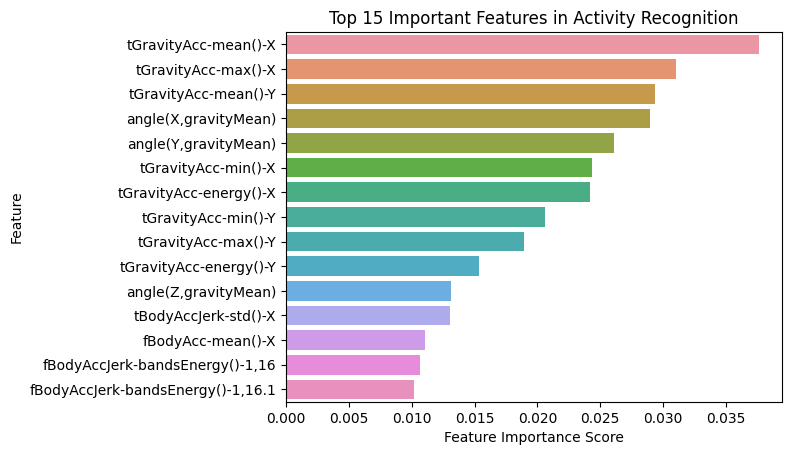

In [6]:
feat_importances = pd.Series(clf.feature_importances_, index=X_train.columns)
top_features = feat_importances.nlargest(15)
sns.barplot(x=top_features, y=top_features.index)
plt.title("Top 15 Important Features in Activity Recognition")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.show()


### Feature Analysis and Interpretation

The feature importance analysis revealed that several gravity- and orientation-related features contributed most to the model’s predictions, including `tGravityAcc-mean()-X`, `tGravityAcc-max()-X`, `tGravityAcc-mean()-Y`, `angle(X,gravityMean)`, `angle(Y,gravityMean)`, `tGravityAcc-mean()`, and `tGravityAcc-energy()-X`. These features represent the low-frequency components of acceleration strongly influenced by gravity, providing information about the body’s orientation and posture. The `tGravityAcc-mean()` and `tGravityAcc-max()` features indicate the average and peak gravitational acceleration along specific axes, reflecting how the body or smartphone is tilted relative to the earth. The `tGravityAcc-energy()` feature quantifies the overall variation or oscillation of the gravity signal along an axis, while the `angle(X,gravityMean)` and `angle(Y,gravityMean)` features encode the angular alignment of the phone relative to the gravity vector, effectively capturing body orientation in space. Collectively, these features help the model distinguish between static postures such as LAYING, SITTING, and STANDING, as well as dynamic activities like WALKING and stair climbing, because each activity produces a characteristic pattern of gravity alignment and body tilt. The prominence of these features indicates that the model relies heavily on posture and orientation information rather than raw motion magnitude to differentiate activities, highlighting that the orientation of the body relative to gravity is a key determinant in accurate human activity recognition.


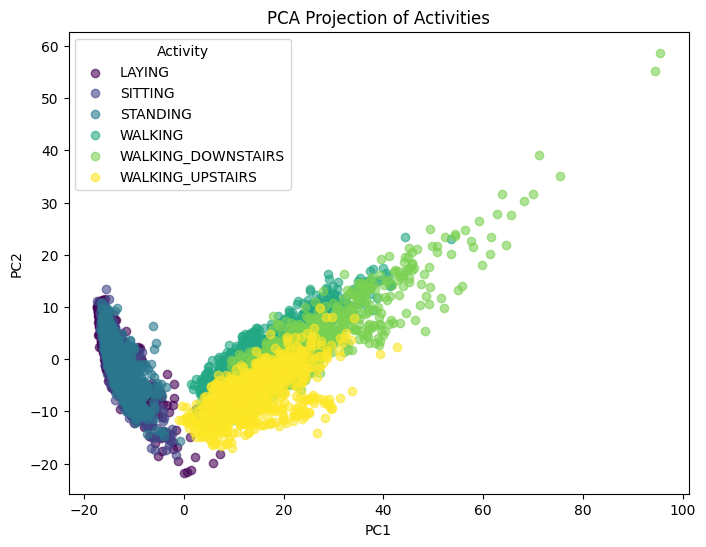

In [7]:
# Fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# Map activity labels to colors
unique_labels = np.unique(y_train_enc)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))

plt.figure(figsize=(8,6))

for i, label in enumerate(unique_labels):
    plt.scatter(
        X_pca[y_train_enc == label, 0],
        X_pca[y_train_enc == label, 1],
        color=colors[i],
        label=le.inverse_transform([label])[0], 
        alpha=0.6
    )

plt.title("PCA Projection of Activities")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Activity")
plt.show()
